<a href="https://colab.research.google.com/github/inhajourney/AIFFEL_quest_cr/blob/main/Project_Embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WEAT 구현하기

In [5]:
# 이 코드를 Colab 셀에서 실행
import time
from IPython.display import display, Javascript

display(Javascript('''
  function ClickConnect(){
    console.log("연결 유지 중...");
    document.querySelector("colab-connect-button").click()
  }
  setInterval(ClickConnect, 60000)
'''))

print("✅ 자동 연결 유지 활성화!")

<IPython.core.display.Javascript object>

✅ 자동 연결 유지 활성화!


In [6]:
!wget -q -O /content/ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt

# 확인
import os
if os.path.exists('/content/ratings_train.txt'):
    print("✅ 파일 준비 완료!")
    file_size = os.path.getsize('/content/ratings_train.txt') / (1024*1024)
    print(f"파일 크기: {file_size:.2f} MB")
else:
    print("❌ 파일이 없습니다")

✅ 파일 준비 완료!
파일 크기: 13.95 MB


In [7]:
# KoNLPy 설치
!pip install konlpy

# Java가 필요하므로 확인
!apt-get install -y openjdk-8-jdk

print("✅ 설치 완료!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-8-jdk is already the newest version (8u472-ga-1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
✅ 설치 완료!


In [8]:
from konlpy.tag import Okt
import re

file_path = '/content/ratings_train.txt'
okt = Okt()
tokenized = []

print("토큰화 시작...")

with open(file_path, 'r', encoding='utf-8') as file:
    file.readline()  # 헤더 건너뛰기

    count = 0
    for line in file:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            review = parts[1]
            review = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]', '', review)
            tokenized_line = okt.morphs(review, stem=True)

            if tokenized_line:
                tokenized.append(tokenized_line)

        count += 1
        if count % 10000 == 0:
            print(f"  {count}개 처리 중...")

        # 테스트용으로 일부만 처리 (선택사항)
        if count >= 50000:  # 5만개만 먼저 테스트
            break

print(f"\n✅ 토큰화 완료!")
print(f"총 {len(tokenized)}개 문장")
print(f"\n첫 3개 예시:")
for i, tokens in enumerate(tokenized[:3]):
    print(f"{i+1}: {tokens}")

토큰화 시작...
  10000개 처리 중...
  20000개 처리 중...
  30000개 처리 중...
  40000개 처리 중...
  50000개 처리 중...

✅ 토큰화 완료!
총 49576개 문장

첫 3개 예시:
1: ['아', '더빙', '진짜', '짜증나다', '목소리']
2: ['흠', '포스터', '보고', '초딩', '영화', '줄', '오버', '연기', '조차', '가볍다', '않다']
3: ['너', '무재', '밓었', '다그', '래서', '보다', '추천', '한', '다']


In [9]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

print("슝~")

슝~


In [10]:
target_X = {
    '장미': [4.1, 1.2, -2.4, 0.5, 4.1],
    '튤립': [3.1, 0.5, 3.6, 1.7, 5.8],
    '백합': [2.9, -1.3, 0.4, 1.1, 3.7],
    '데이지': [5.4, 2.5, 4.6, -1.0, 3.6]
}
target_Y = {
    '거미': [-1.5, 0.2, -0.6, -4.6, -5.3],
    '모기': [0.4, 0.7, -1.9, -4.5, -2.9],
    '파리': [0.9, 1.4, -2.3, -3.9, -4.7],
    '메뚜기': [0.7, 0.9, -0.4, -4.1, -3.9]
}
attribute_A = {
    '사랑':[2.8,  4.2, 4.3,  0.3, 5.0],
    '행복':[3.8,  3. , -1.2,  4.4, 4.9],
    '웃음':[3.7, -0.3,  1.2, -2.5, 3.9]
}
attribute_B = {
    '재난': [-0.2, -2.8, -4.7, -4.3, -4.7],
    '고통': [-4.5, -2.1,  -3.8, -3.6, -3.1],
    '증오': [-3.6, -3.3, -3.5,  -3.7, -4.4]
}

print("슝~")

슝~


In [11]:
X = np.array([v for v in target_X.values()])
Y = np.array([v for v in target_Y.values()])
print(X)
print(Y)

[[ 4.1  1.2 -2.4  0.5  4.1]
 [ 3.1  0.5  3.6  1.7  5.8]
 [ 2.9 -1.3  0.4  1.1  3.7]
 [ 5.4  2.5  4.6 -1.   3.6]]
[[-1.5  0.2 -0.6 -4.6 -5.3]
 [ 0.4  0.7 -1.9 -4.5 -2.9]
 [ 0.9  1.4 -2.3 -3.9 -4.7]
 [ 0.7  0.9 -0.4 -4.1 -3.9]]


In [12]:
A = np.array([v for v in attribute_A.values()])
B = np.array([v for v in attribute_B.values()])
print(A)
print(B)

[[ 2.8  4.2  4.3  0.3  5. ]
 [ 3.8  3.  -1.2  4.4  4.9]
 [ 3.7 -0.3  1.2 -2.5  3.9]]
[[-0.2 -2.8 -4.7 -4.3 -4.7]
 [-4.5 -2.1 -3.8 -3.6 -3.1]
 [-3.6 -3.3 -3.5 -3.7 -4.4]]


In [13]:
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B #, c_a, c_b

print(s(target_X['장미'], A, B))

0.6457646122337399


In [14]:
print(s(target_Y['거미'], A, B))

-0.794002342033094


In [15]:
print(s(X, A, B))
print(round(np.mean(s(X, A, B)), 3))

[0.29551989 0.51723181 0.26499096 0.50924109]
0.397


In [16]:
print(s(Y, A, B))
print(round(np.mean(s(Y, A, B)), 3))

[-0.44713039 -0.28310853 -0.33144878 -0.26030641]
-0.33


In [17]:
def weat_score(X, Y, A, B):

    s_X = s(X, A, B)
    s_Y = s(Y, A, B)

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    return  (mean_X-mean_Y)/std_dev

print(round(weat_score(X, Y, A, B), 3))

1.932


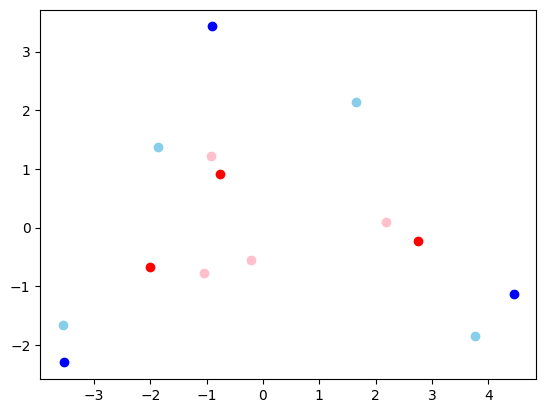

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pc_A = pca.fit_transform(A)
pc_B = pca.fit_transform(B)
pc_X = pca.fit_transform(X)
pc_Y = pca.fit_transform(Y)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(pc_A[:,0],pc_A[:,1], c='blue', label='A')
ax.scatter(pc_B[:,0],pc_B[:,1], c='red', label='B')
ax.scatter(pc_X[:,0],pc_X[:,1], c='skyblue', label='X')
ax.scatter(pc_Y[:,0],pc_Y[:,1], c='pink', label='Y')

# 사전학습된 Word Embedding에 WEAT 적용

In [19]:
!mkdir -p ~/work/weat/data
!ln -s ~/data/* ~/work/weat/data/

ln: failed to create symbolic link '/root/work/weat/data/*': File exists


In [20]:
!pip install gensim==4.3.2

# 의존성 연결을 위해 다운그레이드를 진행합니다.
!pip install scipy==1.12.0 numpy==1.26.2

  Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached numpy-1.26.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.8 MB)
Using cached numpy-1.26.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
esda 2.8.1 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
jax 0.7.2 requires numpy>=2.0, 

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
# ========== 셀 1: 패키지 설치 ==========
!pip uninstall numpy scipy gensim scikit-learn nltk -y
!pip install numpy==1.26.4 scipy==1.11.4 gensim==4.3.2 scikit-learn==1.3.2 nltk

# ========== 셀 2: 런타임 재시작 ==========
import os
os.kill(os.getpid(), 9)

# ========== 런타임이 재시작됩니다 ==========

# ========== 셀 3: 버전 확인 (재시작 후) ==========
import numpy as np
import scipy
import gensim

print(f"✅ NumPy: {np.__version__}")
print(f"✅ SciPy: {scipy.__version__}")
print(f"✅ Gensim: {gensim.__version__}")

# ========== 셀 4: 이제 정상 작동 ==========
import os
from gensim.models import KeyedVectors
import numpy as np

data_dir = os.path.join(os.getenv("HOME"), 'work/weat/data')
print(f"데이터 디렉토리: {data_dir}")


Found existing installation: numpy 1.26.2
Uninstalling numpy-1.26.2:
  Successfully uninstalled numpy-1.26.2
Found existing installation: scipy 1.12.0
Uninstalling scipy-1.12.0:
  Successfully uninstalled scipy-1.12.0
Found existing installation: gensim 4.3.2
Uninstalling gensim-4.3.2:
  Successfully uninstalled gensim-4.3.2
Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
Found existing installation: nltk 3.9.2
Uninstalling nltk-3.9.2:
  Successfully uninstalled nltk-3.9.2
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.11.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached gensim-4.3.2-cp312-cp312-linux_x86_64.whl
  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached nltk-3.9.2-py3-none-any.whl.metadata (3.2 kB)
Using c

In [2]:
import os
import gdown

# 디렉토리 생성
model_dir = '/content/GoogleNews-vectors-negative300.bin'
os.makedirs('/content', exist_ok=True)

print("📥 GoogleNews Word2Vec 모델 다운로드 중...")
print("⚠️  약 1.5GB 파일이므로 3-5분 정도 소요됩니다.\n")

# Google Drive에서 다운로드
url = 'https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM'
gdown.download(url, model_dir, quiet=False)

print("\n✅ 다운로드 완료!")

📥 GoogleNews Word2Vec 모델 다운로드 중...
⚠️  약 1.5GB 파일이므로 3-5분 정도 소요됩니다.



Downloading...
From (original): https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM
From (redirected): https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM&confirm=t&uuid=e17b82ea-e74a-4fdd-97aa-a9d5ce7de1c3
To: /content/GoogleNews-vectors-negative300.bin
100%|██████████| 1.65G/1.65G [00:25<00:00, 64.1MB/s]


✅ 다운로드 완료!


In [5]:
import os

model_dir = '/content/GoogleNews-vectors-negative300.bin'

# 파일 존재 및 크기 확인
if os.path.exists(model_dir):
    size_mb = os.path.getsize(model_dir) / (1024 * 1024)
    print(f"✅ 파일 존재: {model_dir}")
    print(f"파일 크기: {size_mb:.2f} MB")

    # 파일 타입 확인
    !file {model_dir}

    # 첫 몇 바이트 확인
    with open(model_dir, 'rb') as f:
        header = f.read(20)
        print(f"\n파일 헤더: {header}")
else:
    print("❌ 파일 없음")

✅ 파일 존재: /content/GoogleNews-vectors-negative300.bin
파일 크기: 1570.75 MB
/content/GoogleNews-vectors-negative300.bin: gzip compressed data, was "GoogleNews-vectors-negative300.bin", last modified: Thu Dec 12 00:12:48 2013, max compression, from Unix, original size modulo 2^32 3644258522

파일 헤더: b'\x1f\x8b\x08\x08\x80\xff\xa8R\x02\x03GoogleNews'


In [6]:
import os

# gunzip으로 압축 해제 (가장 빠름)
compressed = '/content/GoogleNews-vectors-negative300.bin'
decompressed = '/content/GoogleNews-vectors-negative300-decompressed.bin'

if os.path.exists(decompressed):
    print("✅ 이미 압축 해제됨")
else:
    print("📦 압축 해제 중... (2-3분 소요)")
    !gunzip -c {compressed} > {decompressed}
    print("✅ 압축 해제 완료!")

# 파일 크기 확인
size_gb = os.path.getsize(decompressed) / (1024**3)
print(f"압축 해제된 파일: {size_gb:.2f} GB")

📦 압축 해제 중... (2-3분 소요)
✅ 압축 해제 완료!
압축 해제된 파일: 3.39 GB


In [7]:
from gensim.models import KeyedVectors
import numpy as np

# ========== 모델 로드 ==========
print("모델 로딩 중... (1-2분)")
w2v = KeyedVectors.load_word2vec_format(
    '/content/GoogleNews-vectors-negative300-decompressed.bin',
    binary=True,
    limit=500000  # 50만개만
)
print(f"✅ 로드 완료! Vocabulary: {len(w2v):,}개")

# ========== WEAT 함수 ==========
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

def s(w, A, B):
    mean_A = np.mean([cosine_similarity(w, a) for a in A])
    mean_B = np.mean([cosine_similarity(w, b) for b in B])
    return mean_A - mean_B

def weat_score(X, Y, A, B):
    return sum([s(x, A, B) for x in X]) - sum([s(y, A, B) for y in Y])

# ========== WEAT 실행 ==========
target_X = ['rose', 'daisy', 'tulip', 'lily', 'orchid']
target_Y = ['ant', 'bee', 'spider', 'wasp', 'mosquito']
attribute_A = ['pleasant', 'beautiful', 'wonderful', 'happy', 'lovely']
attribute_B = ['unpleasant', 'ugly', 'awful', 'sad', 'horrible']

# 벡터 변환
X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

# 점수 계산
score = weat_score(X, Y, A, B)

print(f"\n📊 WEAT 결과:")
print(f"Score: {score:.4f}")
print(f"\n💡 해석: {'꽃이 긍정과 더 연관됨' if score > 0 else '곤충이 긍정과 더 연관됨'}")

모델 로딩 중... (1-2분)
✅ 로드 완료! Vocabulary: 500,000개

📊 WEAT 결과:
Score: 0.3754

💡 해석: 꽃이 긍정과 더 연관됨


In [8]:
w2v

In [9]:
w2v['happy']

array([-5.18798828e-04,  1.60156250e-01,  1.60980225e-03,  2.53906250e-02,
        9.91210938e-02, -8.59375000e-02,  3.24218750e-01, -2.17285156e-02,
        1.34765625e-01,  1.10351562e-01, -1.04980469e-01, -2.90527344e-02,
       -2.38037109e-02, -4.02832031e-02, -3.68652344e-02,  2.32421875e-01,
        3.20312500e-01,  1.01074219e-01,  5.83496094e-02, -2.91824341e-04,
       -3.29589844e-02,  2.11914062e-01,  4.32128906e-02, -8.59375000e-02,
        2.81250000e-01, -1.78222656e-02,  3.79943848e-03, -1.71875000e-01,
        2.06054688e-01, -1.85546875e-01,  3.73535156e-02, -1.21459961e-02,
        2.04101562e-01, -3.80859375e-02,  3.61328125e-02, -8.15429688e-02,
        8.44726562e-02,  9.37500000e-02,  1.44531250e-01,  7.42187500e-02,
        2.51953125e-01, -7.91015625e-02,  8.69140625e-02,  1.58691406e-02,
        1.09375000e-01, -2.23632812e-01, -5.15747070e-03,  1.68945312e-01,
       -1.36718750e-01, -2.51464844e-02, -3.85742188e-02, -1.33056641e-02,
        1.38671875e-01,  

In [10]:
w2v.most_similar(positive=['happy'])

[('glad', 0.7408890724182129),
 ('pleased', 0.6632170677185059),
 ('ecstatic', 0.6626912355422974),
 ('overjoyed', 0.6599286794662476),
 ('thrilled', 0.6514049172401428),
 ('satisfied', 0.6437949538230896),
 ('proud', 0.636042058467865),
 ('delighted', 0.627237856388092),
 ('disappointed', 0.6269949674606323),
 ('excited', 0.6247665286064148)]

In [11]:
w2v.most_similar(positive=['family'])

[('relatives', 0.6662653088569641),
 ('familiy', 0.6517067551612854),
 ('families', 0.6252894997596741),
 ('siblings', 0.6140849590301514),
 ('friends', 0.6128394603729248),
 ('mother', 0.6065612435340881),
 ('aunt', 0.5811319947242737),
 ('grandparents', 0.5762072205543518),
 ('father', 0.5717043876647949),
 ('Family', 0.5672314763069153)]

In [12]:
w2v.most_similar(positive=['school'])

[('elementary', 0.7868632078170776),
 ('schools', 0.7411909103393555),
 ('elementary_schools', 0.6597153544425964),
 ('kindergarten', 0.6529811024665833),
 ('eighth_grade', 0.6488089561462402),
 ('School', 0.6477997303009033),
 ('teacher', 0.63824063539505),
 ('students', 0.6301522850990295),
 ('classroom', 0.6281620264053345),
 ('Schools', 0.6172096133232117)]

In [13]:
import numpy as np

def cosine_similarity(v1, v2):
    """두 벡터 간의 코사인 유사도 계산"""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

def s(w, A, B):
    """
    단어 w와 속성 집합 A, B 간의 연관성 차이
    s(w, A, B) = mean(cos(w, a)) - mean(cos(w, b))
    """
    mean_A = np.mean([cosine_similarity(w, a) for a in A])
    mean_B = np.mean([cosine_similarity(w, b) for b in B])
    return mean_A - mean_B

def weat_score(X, Y, A, B):
    """
    WEAT (Word Embedding Association Test) 점수 계산
    """
    sum_X = sum([s(x, A, B) for x in X])
    sum_Y = sum([s(y, A, B) for y in Y])
    weat = sum_X - sum_Y
    return weat

def weat_effect_size(X, Y, A, B):
    """
    WEAT 효과 크기 계산
    """
    s_X = [s(x, A, B) for x in X]
    s_Y = [s(y, A, B) for y in Y]
    mean_diff = np.mean(s_X) - np.mean(s_Y)
    std_dev = np.std(s_X + s_Y)
    effect_size = mean_diff / std_dev if std_dev != 0 else 0
    return effect_size

print("✅ WEAT 함수 정의 완료!")

✅ WEAT 함수 정의 완료!


In [15]:
import os
from gensim.models import KeyedVectors
import numpy as np

# ========== 1. 압축 해제 (아직 안 했다면) ==========
compressed = '/content/GoogleNews-vectors-negative300.bin'
decompressed = '/content/GoogleNews-vectors-negative300-decompressed.bin'

if not os.path.exists(decompressed):
    print("📦 압축 해제 중... (2-3분)")
    !gunzip -c {compressed} > {decompressed}
    print("✅ 압축 해제 완료!")
else:
    print("✅ 압축 해제된 파일 존재")

# ========== 2. 모델 로드 ==========
print("\n모델 로딩 중... (1-2분)")
w2v = KeyedVectors.load_word2vec_format(
    decompressed,  # 올바른 경로 사용
    binary=True,
    limit=500000  # 메모리 절약
)
print(f"✅ 모델 로드 완료! Vocabulary: {len(w2v):,}개")

# ========== 3. WEAT 함수 정의 ==========
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

def s(w, A, B):
    mean_A = np.mean([cosine_similarity(w, a) for a in A])
    mean_B = np.mean([cosine_similarity(w, b) for b in B])
    return mean_A - mean_B

def weat_score(X, Y, A, B):
    sum_X = sum([s(x, A, B) for x in X])
    sum_Y = sum([s(y, A, B) for y in Y])
    return sum_X - sum_Y

def weat_effect_size(X, Y, A, B):
    s_X = [s(x, A, B) for x in X]
    s_Y = [s(y, A, B) for y in Y]
    mean_diff = np.mean(s_X) - np.mean(s_Y)
    std_dev = np.std(s_X + s_Y)
    return mean_diff / std_dev if std_dev != 0 else 0

# ========== 4. 단어 집합 정의 ==========
target_X = ['rose', 'daisy', 'tulip', 'lily', 'orchid']  # 꽃
target_Y = ['ant', 'bee', 'spider', 'wasp', 'mosquito']  # 곤충
attribute_A = ['pleasant', 'beautiful', 'wonderful', 'happy', 'lovely']  # 긍정
attribute_B = ['unpleasant', 'ugly', 'awful', 'sad', 'horrible']  # 부정

# ========== 5. 벡터 변환 ==========
X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

# ========== 6. WEAT 점수 계산 ==========
score = weat_score(X, Y, A, B)
effect = weat_effect_size(X, Y, A, B)

print(f"\n📊 WEAT 결과:")
print(f"WEAT Score: {score:.4f}")
print(f"Effect Size: {effect:.4f}")

# 해석
if score > 0:
    print(f"\n💡 해석: 꽃이 긍정 단어와 더 강하게 연관됨")
else:
    print(f"\n💡 해석: 곤충이 긍정 단어와 더 강하게 연관됨")

✅ 압축 해제된 파일 존재

모델 로딩 중... (1-2분)
✅ 모델 로드 완료! Vocabulary: 500,000개

📊 WEAT 결과:
WEAT Score: 0.3754
Effect Size: 1.3898

💡 해석: 꽃이 긍정 단어와 더 강하게 연관됨


In [16]:
target_X = ['science', 'technology', 'physics', 'chemistry', 'Einstein', 'NASA', 'experiment', 'astronomy']
target_Y = ['poetry', 'art', 'Shakespeare', 'dance', 'literature', 'novel', 'symphony', 'drama']
attribute_A = ['brother', 'father', 'uncle', 'grandfather', 'son', 'he', 'his', 'him']
attribute_B = ['sister', 'mother', 'aunt', 'grandmother', 'daughter', 'she', 'hers', 'her']

X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

weat_score(X, Y, A, B)

0.35718660801649094

In [17]:
target_X = ['pizza', 'coke', 'hamburger', 'ham', 'ramen', 'icecream', 'candy']
target_Y = ['salad', 'fruit', 'vegetable', 'herb', 'root', 'greens', 'wholesome']
attribute_A = ['junk', 'canned', 'convenience', 'frozen', 'fast']
attribute_B = ['health', 'beneficial', 'good', 'nourishing', 'nutritious']

X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

weat_score(X, Y, A, B)

0.8830482102930546

In [18]:
target_X = ['pizza', 'coke', 'hamburger', 'ham', 'ramen', 'icecream', 'candy']
target_Y = ['salad', 'fruit', 'vegetable', 'herb', 'root', 'greens', 'wholesome']
attribute_A = ['book', 'essay', 'dictionary', 'magazine', 'novel']
attribute_B = ['news', 'report', 'statement', 'broadcast', 'word']

X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

weat_score(X, Y, A, B)

-0.010438445955514908

In [19]:
target_X = ['pizza', 'coke', 'hamburger', 'fries', 'steak', 'bacon', 'sausage']
target_Y = ['carrot', 'broccoli', 'spinach', 'lettuce', 'cucumber', 'avocado', 'peas']
attribute_A = ['delicious', 'tasty', 'yummy', 'flavorful', 'savory', 'appetizing']
attribute_B = ['healthy', 'nutritious', 'wholesome', 'organic', 'balanced', 'nourishing']

X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

weat_score(X, Y, A, B)

0.8025694862008095

In [20]:
#메모리를 다시 비워줍시다.
del w2v
print("삭제 완료")

삭제 완료


# 직접 만드는 Word Embedding에 WEAT 적용

In [21]:
!mkdir -p ~/work/weat/data && cd ~/data && unzip synopsis.zip -d ~/work/weat/data/

/bin/bash: line 1: cd: /root/data: No such file or directory


In [25]:
from google.colab import files
import zipfile
import os

# 1. 파일 업로드
print("📤 synopsis.zip 파일을 업로드하세요:")
uploaded = files.upload()

# 2. 업로드된 zip 파일 이름 확인
zip_filename = list(uploaded.keys())[0]
print(f"\n✅ 업로드 완료: {zip_filename}")

# 3. 압축 해제
print("\n📦 압축 해제 중...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("✅ 압축 해제 완료!")

# 4. 압축 해제된 파일 찾기
print("\n📂 압축 해제된 파일들:")
!find /content -name "*.txt" -type f

# 5. synopsis.txt 파일 경로 찾기
import glob
txt_files = glob.glob('/content/**/synopsis.txt', recursive=True)

if txt_files:
    file_path = txt_files[0]
    print(f"\n✅ 파일 찾음: {file_path}")

    # 6. 파일 읽기
    print("\n📄 파일 내용 (처음 20줄):")
    print("=" * 50)
    with open(file_path, 'r', encoding='utf-8') as file:
        for i in range(20):
            line = file.readline()
            if not line:
                break
            print(f"{i+1:2d}: {line}", end='')
    print("=" * 50)
else:
    print("\n❌ synopsis.txt 파일을 찾을 수 없습니다")
    print("\n압축 해제된 전체 구조:")
    !tree /content -L 3

📤 synopsis.zip 파일을 업로드하세요:


Saving synopsis.zip to synopsis.zip

✅ 업로드 완료: synopsis.zip

📦 압축 해제 중...
✅ 압축 해제 완료!

📂 압축 해제된 파일들:
/content/synopsis_horror.txt
/content/synopsis_western.txt
/content/synopsis_crime.txt
/content/synopsis_etc.txt
/content/synopsis_gen.txt
/content/synopsis_fantasy.txt
/content/synopsis_adult.txt
/content/synopsis_historical.txt
/content/synopsis_adventure.txt
/content/synopsis_family.txt
/content/synopsis_documentary.txt
/content/synopsis_war.txt
/content/synopsis_action.txt
/content/synopsis_romance.txt
/content/synopsis_musical.txt
/content/synopsis_animation.txt
/content/synopsis_comedy.txt
/content/synopsis_thriller.txt
/content/synopsis_SF.txt
/content/synopsis_drama.txt
/content/synopsis_show.txt
/content/synopsis.txt
/content/synopsis_art.txt
/content/ratings_train.txt
/content/synopsis_mystery.txt

✅ 파일 찾음: /content/synopsis.txt

📄 파일 내용 (처음 20줄):
 1: 사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 2:  젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 3:  어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를

In [28]:
import os

# Colab 경로로 수정
data_dir = '/content/'
file_name = os.path.join(data_dir, 'synopsis.txt')

# 파일 존재 확인
if os.path.exists(file_name):
    print(f"✅ 파일 찾음: {file_name}\n")

    with open(file_name, 'r', encoding='utf-8') as file:
        for i in range(20):
            line = file.readline()
            if not line:
                break
            print(line, end='')
else:
    print(f"❌ 파일 없음: {file_name}")
    print("\n파일을 먼저 업로드하고 압축 해제하세요!")

✅ 파일 찾음: /content/synopsis.txt

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.
 은수를 잊지 못하는 상우는 미련과 집착의 감정을 이기지 못하고 서울과 강릉을 오간다.
유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 '애국심'이라는 성역에 일침을 가하는 다큐멘터리. 재작년 전국 민족민주 유가족협의회의 장기농성을 다룬 인상적인 다큐멘터리 <민들레>를 만들었던 독립영화집단 '빨간 눈사람'이 우리 사회 구석구석을 발빠르게 돌아다니며 애국심과 민족주의가 강요되는 현장을 발굴하여 카메라에 담았다. 박홍 서강대 명예총장, 이도형 '한국논단' 발행인, 축구해설자 신문선, 홍세화, 박노해 등 사회 각계의 '스타'들이 등장해 저마다의 확고한 신념을 성토한다. 감독 이경순과 최하동하는 이 작품을 위해 3년간 백여 명을 인터뷰했다고 한다. 2001 올해의 독립영화상 수상.
 민족과 국가란 공동체에서 부단히 권력과 부를 얻는 자, 나아가 민족과 국가란 공동체에서 얻은 신분과 부귀를 영원히 그의 자손에게 대물림하려는 자, 그래서 

In [29]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc

!pip install konlpy

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,885 kB]
Get:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubun

In [30]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc

!pip install konlpy

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
108 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as r

In [31]:
# 약 15분정도 걸립니다.
from konlpy.tag import Okt

okt = Okt()
tokenized = []

with open(file_name, 'r') as file:
    while True:
        line = file.readline()
        if not line: break
        words = okt.pos(line, stem=True, norm=True)
        res = []
        for w in words:
            if w[1] in ["Noun"]:      # "Adjective", "Verb" 등을 포함할 수도 있습니다.
                res.append(w[0])    # 명사일 때만 tokenized 에 저장하게 됩니다.
        tokenized.append(res)

print("슝~")

슝~


In [32]:
print(len(tokenized))

71156


In [33]:
from gensim.models import Word2Vec

# tokenized에 담긴 데이터를 가지고 나만의 Word2Vec을 생성합니다. (Gensim 4.0 기준)
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
model.wv.most_similar(positive=['영화'])

# Gensim 3.X 에서는 아래와 같이 생성합니다.
# model = Word2Vec(tokenized, size=100, window=5, min_count=3, sg=0)
# model.most_similar(positive=['영화'])

[('작품', 0.8900510668754578),
 ('다큐멘터리', 0.8530371785163879),
 ('드라마', 0.8193702101707458),
 ('영화로', 0.8071516752243042),
 ('주제', 0.7843893766403198),
 ('감동', 0.7822186350822449),
 ('형식', 0.7796468734741211),
 ('소재', 0.7753971815109253),
 ('코미디', 0.775361955165863),
 ('영감', 0.7618982791900635)]

In [34]:
model.wv.most_similar(positive=['사랑'])

[('행복', 0.7218342423439026),
 ('첫사랑', 0.7200565338134766),
 ('시빌라', 0.710475742816925),
 ('정일', 0.7020003795623779),
 ('나비문신', 0.6922762393951416),
 ('애정', 0.6918821930885315),
 ('만남', 0.6886136531829834),
 ('진심', 0.6827111840248108),
 ('운명', 0.6822307705879211),
 ('연애', 0.679929256439209)]

In [35]:
model.wv.most_similar(positive=['연극'])

[('영감', 0.8831889033317566),
 ('시나리오', 0.8788304924964905),
 ('대본', 0.8781188726425171),
 ('데뷔', 0.8708643913269043),
 ('영화감독', 0.8668224811553955),
 ('각색', 0.8648364543914795),
 ('배우', 0.8632091879844666),
 ('연기', 0.8630642890930176),
 ('뮤지컬', 0.859966516494751),
 ('출연', 0.8577572703361511)]

In [36]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'

def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:#, "Adjective", "Verb"]:
                    result.append((word[0]))
    return ' '.join(result)

print("슝~")

슝~


In [37]:
# 2개의 파일을 처리하는데 10분 가량 걸립니다.
art = read_token(art_txt)
gen = read_token(gen_txt)

synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.


In [38]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])

print(X.shape)

(2, 41082)


In [39]:
print(vectorizer.vocabulary_['영화'])
print(vectorizer.get_feature_names_out()[23976])

23976
영화


In [40]:
m1 = X[0].tocoo()   # art를 TF-IDF로 표현한 sparse matrix를 가져옵니다.
m2 = X[1].tocoo()   # gen을 TF-IDF로 표현한 sparse matrix를 가져옵니다.

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

w1.sort(key=lambda x: x[1], reverse=True)   #art를 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.
w2.sort(key=lambda x: x[1], reverse=True)   #gen을 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.

print('예술영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w1[i][0]], end=', ')

print('\n')

print('일반영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w2[i][0]], end=', ')

예술영화를 대표하는 단어들:
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 대한, 서로, 과연, 다시, 시간, 아들, 소녀, 아내, 다른, 사이, 영화제, 세계, 사실, 하나, 점점, 남편, 감독, 여행, 인생, 발견, 모두, 순간, 우리, 가장, 마지막, 생활, 아빠, 모습, 통해, 죽음, 기억, 비밀, 학교, 음악, 한편, 소년, 생각, 도시, 명의, 사고, 결혼, 전쟁, 때문, 위기, 이제, 최고, 이자, 과거, 일상, 경찰, 상황, 간다, 미국, 결심, 운명, 현실, 관계, 지금, 단편, 여인, 하루, 이름, 이후, 준비, 인간, 감정, 만난, 국제, 처음, 충격, 살인, 누구, 동안, 존재, 그린, 어머니, 연인, 계속, 동생, 작품, 

일반영화를 대표하는 단어들:
자신, 그녀, 영화제, 위해, 사람, 시작, 국제, 영화, 친구, 사랑, 남자, 이야기, 대한, 서울, 여자, 사건, 남편, 아이, 가족, 아버지, 다른, 마을, 시간, 엄마, 아들, 모든, 단편, 마음, 사실, 다시, 세계, 모습, 작품, 통해, 생각, 서로, 세상, 발견, 감독, 아내, 관계, 소녀, 사이, 하나, 우리, 애니메이션, 때문, 여성, 죽음, 과연, 점점, 인간, 생활, 한편, 결혼, 상황, 모두, 기억, 명의, 소년, 여행, 가장, 간다, 순간, 이제, 도시, 비밀, 학교, 과거, 가지, 이자, 경찰, 마지막, 미국, 동안, 전쟁, 주인공, 대해, 존재, 현실, 연출, 사고, 살인, 일상, 어머니, 계속, 사회, 인생, 다큐멘터리, 부문, 섹스, 최고, 바로, 동생, 의도, 하루, 위기, 계획, 정체, 한국, 

In [41]:
n = 15
w1_, w2_ = [], []
for i in range(100):
    w1_.append(vectorizer.get_feature_names_out()[w1[i][0]])
    w2_.append(vectorizer.get_feature_names_out()[w2[i][0]])

# w1에만 있고 w2에는 없는, 예술영화를 잘 대표하는 단어를 15개 추출한다.
target_art, target_gen = [], []
for i in range(100):
    if (w1_[i] not in w2_) and (w1_[i] in model.wv): target_art.append(w1_[i])
    if len(target_art) == n: break

# w2에만 있고 w1에는 없는, 일반영화를 잘 대표하는 단어를 15개 추출한다.
for i in range(100):
    if (w2_[i] not in w1_) and (w2_[i] in model.wv): target_gen.append(w2_[i])
    if len(target_gen) == n: break

In [42]:
print(target_art)

['아빠', '음악', '결심', '운명', '지금', '여인', '이름', '이후', '준비', '감정', '만난', '처음', '충격', '누구', '그린']


In [43]:
print(target_gen)

['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


In [44]:
genre_txt = ['synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_action.txt', 'synopsis_comedy.txt', 'synopsis_war.txt', 'synopsis_horror.txt']
genre_name = ['드라마', '멜로로맨스', '액션', '코미디', '전쟁', '공포(호러)']

print("슝~")

슝~


In [46]:
# 약 10분정도 걸립니다.
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))

synopsis_SF.txt 파일을 읽고 있습니다.
synopsis_family.txt 파일을 읽고 있습니다.
synopsis_show.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.
synopsis_etc.txt 파일을 읽고 있습니다.
synopsis_documentary.txt 파일을 읽고 있습니다.
synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_musical.txt 파일을 읽고 있습니다.
synopsis_mystery.txt 파일을 읽고 있습니다.
synopsis_crime.txt 파일을 읽고 있습니다.
synopsis_historical.txt 파일을 읽고 있습니다.
synopsis_western.txt 파일을 읽고 있습니다.
synopsis_adult.txt 파일을 읽고 있습니다.
synopsis_thriller.txt 파일을 읽고 있습니다.
synopsis_animation.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_adventure.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_fantasy.txt 파일을 읽고 있습니다.


In [47]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

print(X.shape)

(21, 42191)


In [48]:
m = [X[i].tocoo() for i in range(X.shape[0])]

w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)
attributes = []
for i in range(len(w)):
    print(genre_name[i], end=': ')
    attr = []
    j = 0
    while (len(attr) < 15):
        if vectorizer.get_feature_names_out()[w[i][j][0]] in model.wv:
            attr.append(vectorizer.get_feature_names_out()[w[i][j][0]])
            print(vectorizer.get_feature_names_out()[w[i][j][0]], end=', ')
        j += 1
    attributes.append(attr)
    print()

SF: 위해, 자신, 지구, 시작, 사람, 인류, 인간, 미래, 우주, 그녀, 로봇, 세계, 모든, 박사, 우주선, 
가족: 엄마, 아빠, 가족, 영화제, 자신, 위해, 친구, 아주르, 아버지, 시작, 그녀, 아들, 마을, 국제, 낙타, 
공연: 오페라, 사랑, 토스카, 실황, 올레, 자신, 카바, 그녀, 공연, 오텔로, 리골레토, 백작, 프레, 베르디, 위해, 
공포(호러): 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 가족, 악령, 남자, 좀비, 
기타: 영화제, 국제, 서울, 단편, 영화, 자신, 사람, 이야기, 그녀, 남자, 위해, 시작, 사랑, 뉴미디어, 페스티벌, 
다큐멘터리: 영화제, 영화, 다큐, 국제, 다큐멘터리, 사람, 이야기, 대한, 자신, 감독, 위해, 서울, 우리, 시작, 세계, 
드라마: 자신, 영화제, 그녀, 사람, 사랑, 영화, 위해, 시작, 국제, 남자, 친구, 이야기, 엄마, 여자, 아버지, 
멜로로맨스: 그녀, 사랑, 자신, 시작, 남편, 남자, 여자, 사람, 친구, 섹스, 위해, 마음, 결혼, 서로, 아내, 
뮤지컬: 뮤지컬, 사랑, 에스메랄다, 그녀, 음악, 충무로, 모차르트, 영화, 토스카, 자신, 니웨, 카바, 영화제, 바흐, 페뷔스, 
미스터리: 사건, 그녀, 시작, 자신, 위해, 사람, 발견, 사고, 진실, 죽음, 기억, 살인, 친구, 아내, 남자, 
범죄: 사건, 위해, 자신, 경찰, 시작, 그녀, 범죄, 조직, 살인, 사람, 마약, 형사, 남자, 모든, 살해, 
사극: 조선, 위해, 시작, 신기전, 사랑, 자신, 아가멤논, 황제, 그녀, 루안, 최고, 운명, 사람, 하선, 전쟁, 
서부극(웨스턴): 서부, 보안관, 위해, 벌린, 카우보이, 그레이프바인, 헨리, 마을, 자신, 개릿, 아이, 시작, 무법자, 프린트, 마적, 
성인물(에로): 그녀, 남편, 마사지, 자신, 섹스, 관계, 영화, 정사, 남자, 위해, 시작, 여자, 유부녀, 마음, 사랑, 
스릴러: 자신, 그녀, 사건, 

In [49]:
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]
print("슝~")

슝~


In [50]:
X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)

print("슝~")

슝~


In [51]:
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        print(genre_name[i], genre_name[j],matrix[i][j])

SF 가족 -1.204388603568077
SF 공연 -0.2495778575539589
SF 공포(호러) -1.0205976516008377
SF 기타 0.4152604192495346
SF 다큐멘터리 1.0470243096351624
SF 드라마 -0.829225804656744
SF 멜로로맨스 -1.8281756490468979
SF 뮤지컬 0.492633581161499
SF 미스터리 -1.3177905194461346
SF 범죄 -0.37541358172893524
SF 사극 -0.5499351248145103
SF 서부극(웨스턴) -0.29406721517443657
SF 성인물(에로) -1.318629965186119
SF 스릴러 -1.03323570266366
SF 애니메이션 0.3709898144006729
SF 액션 -0.7015498280525208
SF 어드벤처 -0.8734194412827492
SF 전쟁 0.4422195814549923
SF 코미디 -0.8642953932285309
SF 판타지 -0.5062701255083084
가족 공연 0.9548107907176018
가족 공포(호러) 0.18379095569252968
가족 기타 1.619649052619934
가족 다큐멘터리 2.2514129355549812
가족 드라마 0.3751627989113331
가족 멜로로맨스 -0.6237870827317238
가족 뮤지컬 1.6970222145318985
가족 미스터리 -0.11340190842747688
가족 범죄 0.8289749808609486
가족 사극 0.6544534862041473
가족 서부극(웨스턴) 0.9103213846683502
가족 성인물(에로) -0.11424130573868752
가족 스릴러 0.17115290462970734
가족 애니메이션 1.57537841796875
가족 액션 0.5028387680649757
가족 어드벤처 0.3309691697359085
가족 전쟁 1.6466082036495

In [53]:
# 필요한 패키지 모두 import
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 한글 폰트 설치 및 설정
!apt-get update -qq
!apt-get install -qq fonts-nanum

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

print("✅ 설정 완료!")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ 설정 완료!


In [ ]:
import numpy as np;
import seaborn as sns;

np.random.seed(0)

# 한글 지원 폰트
sns.set(font='NanumGothic')

# 마이너스 부호
plt.rcParams['axes.unicode_minus'] = False

ax = sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name, annot=True,  cmap='RdYlGn_r')
ax

# 프로젝트 : 모든 장르 간 편향성 측정해 보기

In [54]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.3.2
1.3.2
0.13.2


In [55]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

In [56]:
# 데이터 디렉토리 찾기
data_dirs = glob.glob('/content/weat/**/data', recursive=True)
if not data_dirs:
    data_dirs = glob.glob('/content/weat/**/', recursive=True)
data_dir = data_dirs[0] if data_dirs else '/content/weat/'

print(f"데이터 디렉토리: {data_dir}")

데이터 디렉토리: /content/weat/


In [62]:
import os
import numpy as np
from konlpy.tag import Okt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer

# 데이터 디렉토리
data_dir = '/content/'

# 장르 정의
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt',
             'synopsis_etc.txt', 'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt',
             'synopsis_musical.txt', 'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt',
             'synopsis_western.txt', 'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt',
             'synopsis_action.txt', 'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt',
             'synopsis_fantasy.txt']

genre_name = ['SF', '가족', '공연', '공포', '기타', '다큐', '드라마', '로맨스', '뮤지컬',
              '미스터리', '범죄', '사극', '서부극', '성인물', '스릴러', '애니',
              '액션', '어드벤처', '전쟁', '코미디', '판타지']

# STEP 1, 2, 3

In [63]:
# ========== STEP 1: 명사 추출 ==========
print("="*60)
print("STEP 1: 명사 추출")
print("="*60)

okt = Okt()

def extract_nouns(text):
    """명사만 추출 (2글자 이상)"""
    return [word for word in okt.nouns(text) if len(word) > 1]

genre_nouns = {}  # 장르별 명사
all_nouns = []    # 전체 명사 (Word2Vec 학습용)

for txt_file, g_name in zip(genre_txt, genre_name):
    file_path = os.path.join(data_dir, txt_file)

    if not os.path.exists(file_path):
        print(f"⚠️  {g_name:10s} - {txt_file} 없음")
        continue

    print(f"📄 {g_name:10s} 처리 중...", end=' ')

    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    genre_docs = []
    for line in lines:
        nouns = extract_nouns(line.strip())
        if nouns:
            genre_docs.append(nouns)
            all_nouns.append(nouns)

    genre_nouns[g_name] = genre_docs
    print(f"{len(genre_docs):4d}개 문서")

print(f"\n✅ 총 {len(all_nouns):,}개 문서 처리 완료!")
print(f"✅ 처리된 장르: {len(genre_nouns)}개\n")

STEP 1: 명사 추출
📄 SF         처리 중... 1020개 문서
📄 가족         처리 중...  416개 문서
📄 공연         처리 중...  334개 문서
📄 공포         처리 중... 3063개 문서
📄 기타         처리 중... 3625개 문서
📄 다큐         처리 중... 7080개 문서
📄 드라마        처리 중... 18988개 문서
📄 로맨스        처리 중... 5732개 문서
📄 뮤지컬        처리 중...  168개 문서
📄 미스터리       처리 중... 1066개 문서
📄 범죄         처리 중... 1680개 문서
📄 사극         처리 중...  238개 문서
📄 서부극        처리 중...   48개 문서
📄 성인물        처리 중... 1625개 문서
📄 스릴러        처리 중... 2246개 문서
📄 애니         처리 중... 8681개 문서
📄 액션         처리 중... 5829개 문서
📄 어드벤처       처리 중...  534개 문서
📄 전쟁         처리 중...  386개 문서
📄 코미디        처리 중... 4610개 문서
📄 판타지        처리 중...  791개 문서

✅ 총 68,160개 문서 처리 완료!
✅ 처리된 장르: 21개



In [64]:
# ========== STEP 2: Word2Vec 학습 ==========
print("="*60)
print("STEP 2: Word2Vec 학습")
print("="*60)

w2v_model = Word2Vec(
    sentences=all_nouns,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=0,
    epochs=10
)

print(f"✅ Vocabulary: {len(w2v_model.wv):,}개 단어")

# 테스트
test_words = ['영화', '사랑', '액션', '공포']
print("\n단어 확인:")
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"  '{word}': {[w for w, s in similar]}")

STEP 2: Word2Vec 학습
✅ Vocabulary: 23,044개 단어

단어 확인:
  '영화': ['다큐멘터리', '작품', '영화로']
  '사랑': ['아르튬', '운명', '진심']
  '액션': ['리얼', '호러', '고어']
  '공포': ['현상', '악몽', '극도']


In [65]:
# ========== STEP 3: 장르별 대표 키워드 추출 ==========
print("\n" + "="*60)
print("STEP 3: 장르별 대표 키워드 추출")
print("="*60)

def get_genre_keywords(genre_docs, w2v_model, top_n=15):
    """TF-IDF로 대표 단어 추출"""
    text_docs = [' '.join(doc) for doc in genre_docs]

    if not text_docs:
        return []

    try:
        tfidf = TfidfVectorizer(max_features=top_n * 3)
        tfidf_matrix = tfidf.fit_transform(text_docs)
        feature_names = tfidf.get_feature_names_out()

        # 평균 TF-IDF 점수
        mean_scores = tfidf_matrix.mean(axis=0).A1
        top_indices = mean_scores.argsort()[-top_n*2:][::-1]

        # 임베딩에 존재하는 단어만
        keywords = []
        for idx in top_indices:
            word = feature_names[idx]
            if word in w2v_model.wv and word not in keywords:
                keywords.append(word)
            if len(keywords) >= top_n:
                break

        return keywords
    except:
        return []


STEP 3: 장르별 대표 키워드 추출


In [66]:
# 각 장르별 키워드 추출
genre_keywords = {}

for g_name, docs in genre_nouns.items():
    keywords = get_genre_keywords(docs, w2v_model, top_n=15)
    genre_keywords[g_name] = keywords
    print(f"{g_name:10s}: {', '.join(keywords[:8])}")

# 중복 제거 (고유성 강화)
print("\n" + "-"*60)
print("중복 제거 (각 장르 고유성 강화)")
print("-"*60)

genre_keywords_unique = {}
for g_name, keywords in genre_keywords.items():
    unique = []
    for word in keywords:
        # 다른 장르에 적게 나타나는 단어 선택
        overlap = sum(1 for other_g, other_w in genre_keywords.items()
                     if other_g != g_name and word in other_w)
        if overlap < 3:  # 3개 미만 장르에만 나타남
            unique.append(word)

    # 최소 10개 확보
    if len(unique) < 10:
        unique = keywords[:15]

    genre_keywords_unique[g_name] = unique[:15]
    print(f"{g_name:10s}: {', '.join(unique[:8])}")

print("\n" + "="*60)
print("✅ STEP 1, 2, 3 완료!")
print("="*60)
print(f"처리된 장르: {len(genre_keywords_unique)}개")
print(f"평균 키워드: {np.mean([len(k) for k in genre_keywords_unique.values()]):.1f}개")
print(f"Vocabulary: {len(w2v_model.wv):,}개")

SF        : 위해, 시작, 자신, 사람, 지구, 인간, 인류, 세계
가족        : 영화제, 가족, 엄마, 국제, 아빠, 친구, 위해, 자신
공연        : 사랑, 오페라, 공연, 자신, 실황, 위해, 시작, 무대
공포        : 시작, 사람, 위해, 친구, 자신, 그녀, 사건, 공포
기타        : 영화제, 국제, 서울, 단편, 영화, 자신, 사람, 그녀
다큐        : 영화제, 국제, 다큐, 영화, 서울, 다큐멘터리, 사람, 이야기
드라마       : 영화제, 자신, 그녀, 시작, 국제, 위해, 사람, 사랑
로맨스       : 그녀, 사랑, 시작, 자신, 남자, 남편, 사람, 여자
뮤지컬       : 사랑, 영화제, 뮤지컬, 충무로, 그녀, 시작, 자신, 에스메랄다
미스터리      : 사건, 시작, 그녀, 자신, 위해, 사람, 발견, 진실
범죄        : 사건, 위해, 시작, 자신, 경찰, 살인, 조직, 그녀
사극        : 조선, 시작, 위해, 자신, 최고, 사람, 사랑, 소리
서부극       : 위해, 보안관, 서부, 마을, 벌린, 시작, 자신, 무법자
성인물       : 그녀, 남편, 영화, 자신, 남자, 위해, 관계, 그린
스릴러       : 그녀, 시작, 자신, 사건, 위해, 사람, 살인, 남자
애니        : 영화제, 애니메이션, 국제, 친구, 위해, 시작, 인디애니페스트, 자신
액션        : 위해, 시작, 자신, 사건, 조직, 사람, 그녀, 경찰
어드벤처      : 위해, 친구, 자신, 시작, 사람, 마을, 비밀, 모험
전쟁        : 전쟁, 시작, 전투, 위해, 작전, 독일군, 부대, 독일
코미디       : 시작, 위해, 자신, 그녀, 사랑, 친구, 사람, 영화제
판타지       : 자신, 시작, 위해, 그녀, 사랑, 사람, 영화제, 세상

------------------------------------------------------------
중복 제거 